# Other High-Level Plots

Besides the core `Heatmap` constructor, ComplexHeatmap provides specialized
high-level functions for common visualization tasks. This tutorial covers
`density_heatmap` and `frequency_heatmap`, which turn distributions into
color-encoded heatmaps -- useful when you have many columns to compare.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## Preparing demo data

We create a matrix with 20 columns: 10 drawn from a normal distribution
and 10 from a shifted uniform distribution. This gives visually distinct
distribution shapes to explore.

In [2]:
np.random.seed(123)
m = np.hstack([
    np.random.randn(100, 10),
    np.random.uniform(-2, 2, (100, 10)) + 0.5,
])
col_names = [f"C{i+1}" for i in range(m.shape[1])]
print(f"Matrix shape: {m.shape}")

Matrix shape: (100, 20)


## Basic density heatmap

`density_heatmap` estimates the density for each column and maps density
values to colors. Quantile lines and mean lines are overlaid by default.

Returns a Heatmap: True


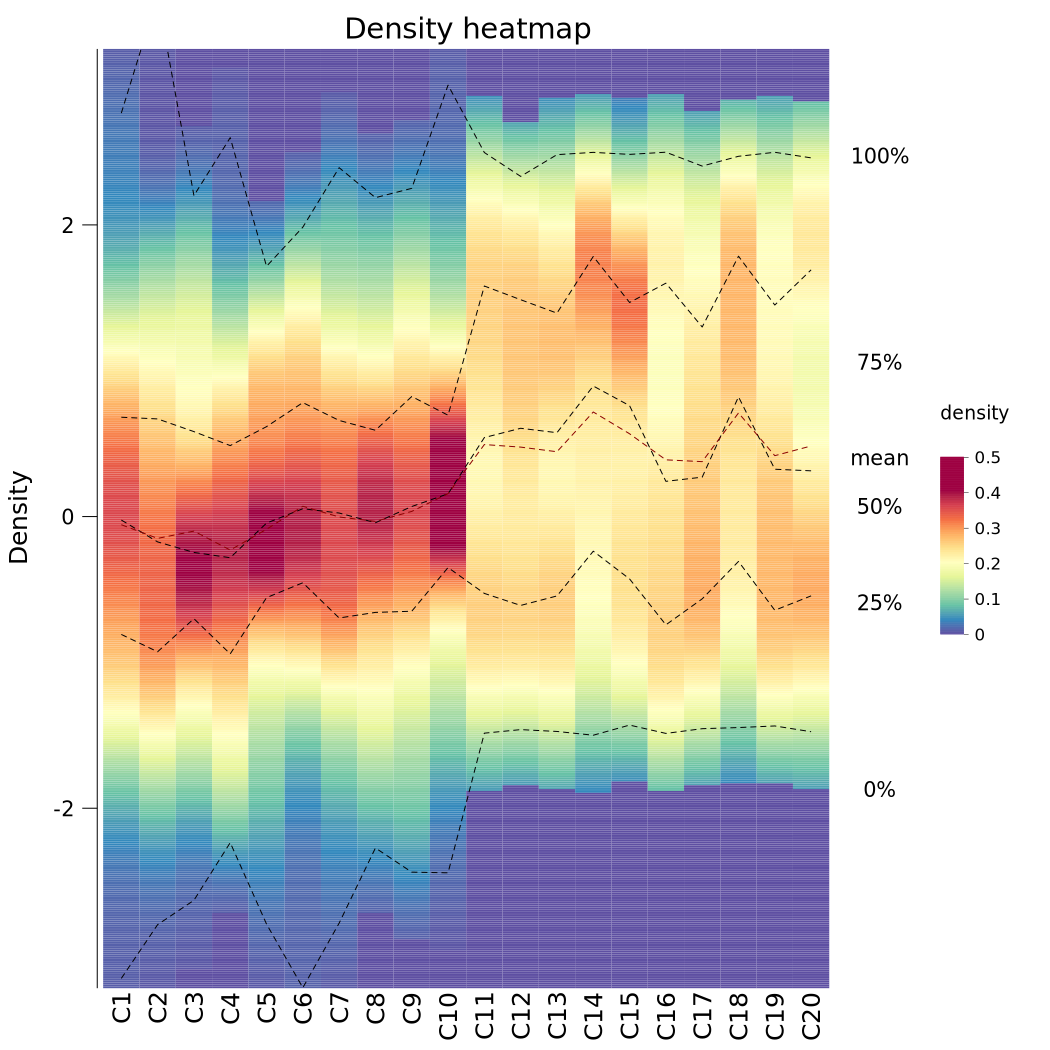

In [3]:
ht = density_heatmap(m, column_names=col_names)
print(f"Returns a Heatmap: {isinstance(ht, Heatmap)}")
ht.draw()

## Verifying density heatmap dimensions

The density heatmap should have the same number of columns as the input,
while the number of rows corresponds to the density estimation grid.

In [4]:
ht.make_layout()
print(f"nrow = {ht.nrow} (density grid points)")
print(f"ncol = {ht.ncol} (should be {m.shape[1]})")

nrow = 500 (density grid points)
ncol = 20 (should be 20)


## Density heatmap with clustering disabled

By default, columns may be clustered. Setting `cluster_columns=False`
keeps the original column order.

In [5]:
ht_no = density_heatmap(
    m,
    column_names=col_names,
    cluster_columns=False,
)
ht_no.make_layout()
co = ht_no.column_order_list()[0]
print(f"Column order is identity: {np.array_equal(co, np.arange(m.shape[1]))}")

Column order is identity: True


## Density heatmap with column clustering (KS distance)

When `cluster_columns=True`, a special Kolmogorov-Smirnov distance is used
by default to measure similarity between distributions. This groups columns
with similar distributional shapes.

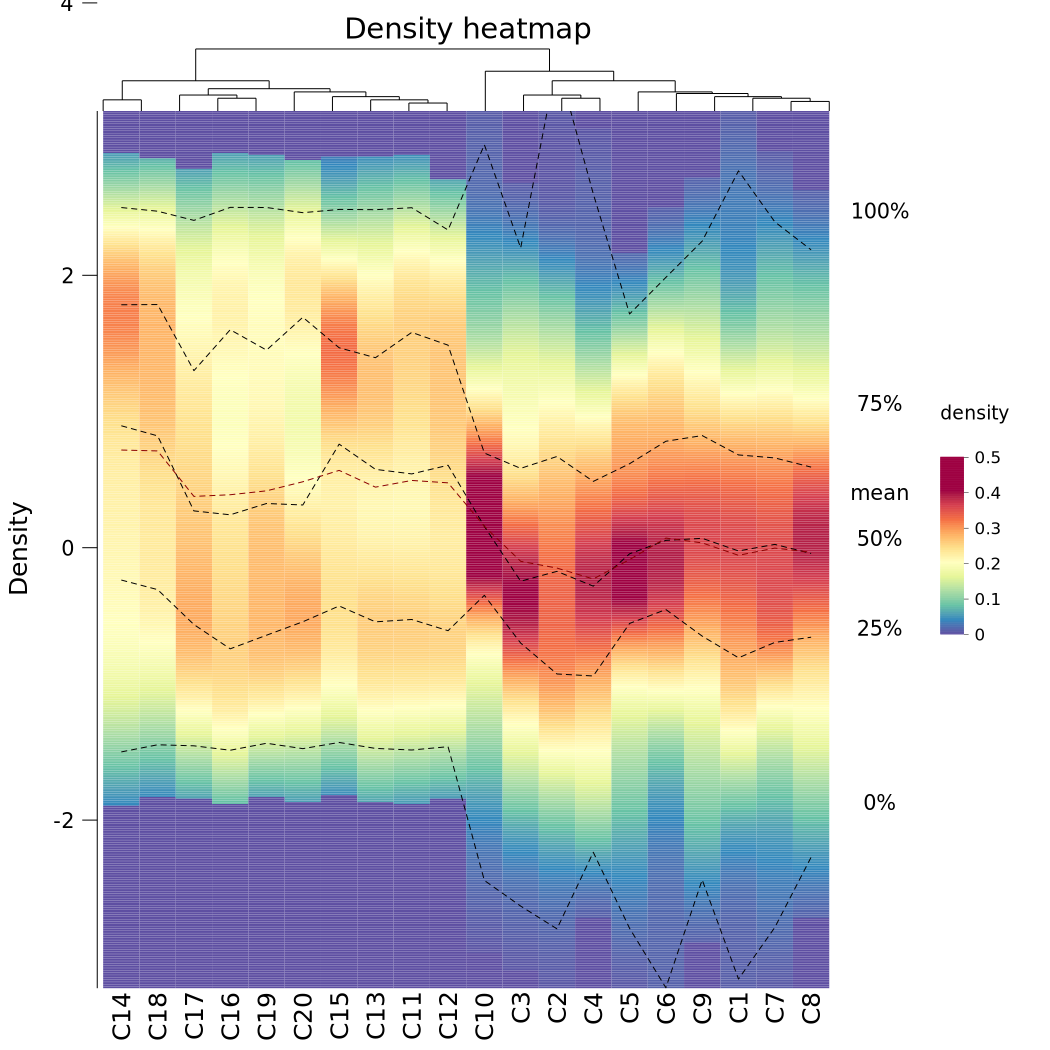

In [6]:
ht_ks = density_heatmap(
    m,
    column_names=col_names,
    cluster_columns=True,
)
ht_ks.draw()

## Density heatmap from a list of arrays

The input can also be a list of arrays (each with a different length).
This is convenient when your data is not a rectangular matrix.

Returns a Heatmap: True


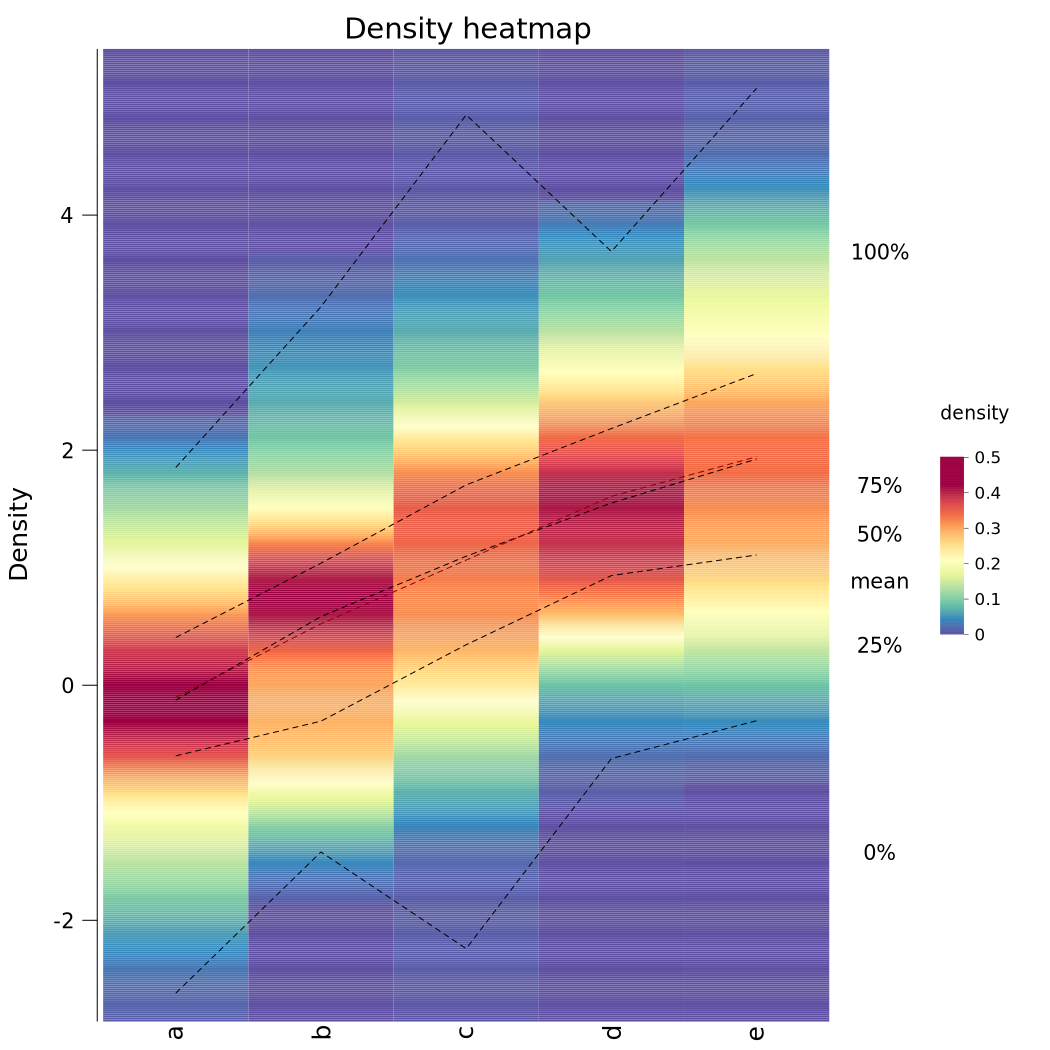

In [7]:
np.random.seed(42)
data_list = [np.random.randn(100) + i * 0.5 for i in range(5)]

ht_list = density_heatmap(data_list, column_names=["a", "b", "c", "d", "e"])
print(f"Returns a Heatmap: {isinstance(ht_list, Heatmap)}")
ht_list.draw()

## Density heatmap with 2D array input

A 2D numpy array is also accepted. Each column is treated as a separate
distribution.

In [8]:
np.random.seed(42)
mat_2d = np.random.randn(100, 5)
ht_2d = density_heatmap(mat_2d, column_names=["v1", "v2", "v3", "v4", "v5"])
print(f"Construction OK: {isinstance(ht_2d, Heatmap)}")

Construction OK: True


## Density heatmap with annotations

Column annotations can be added as top or bottom annotation,
just like a regular heatmap.

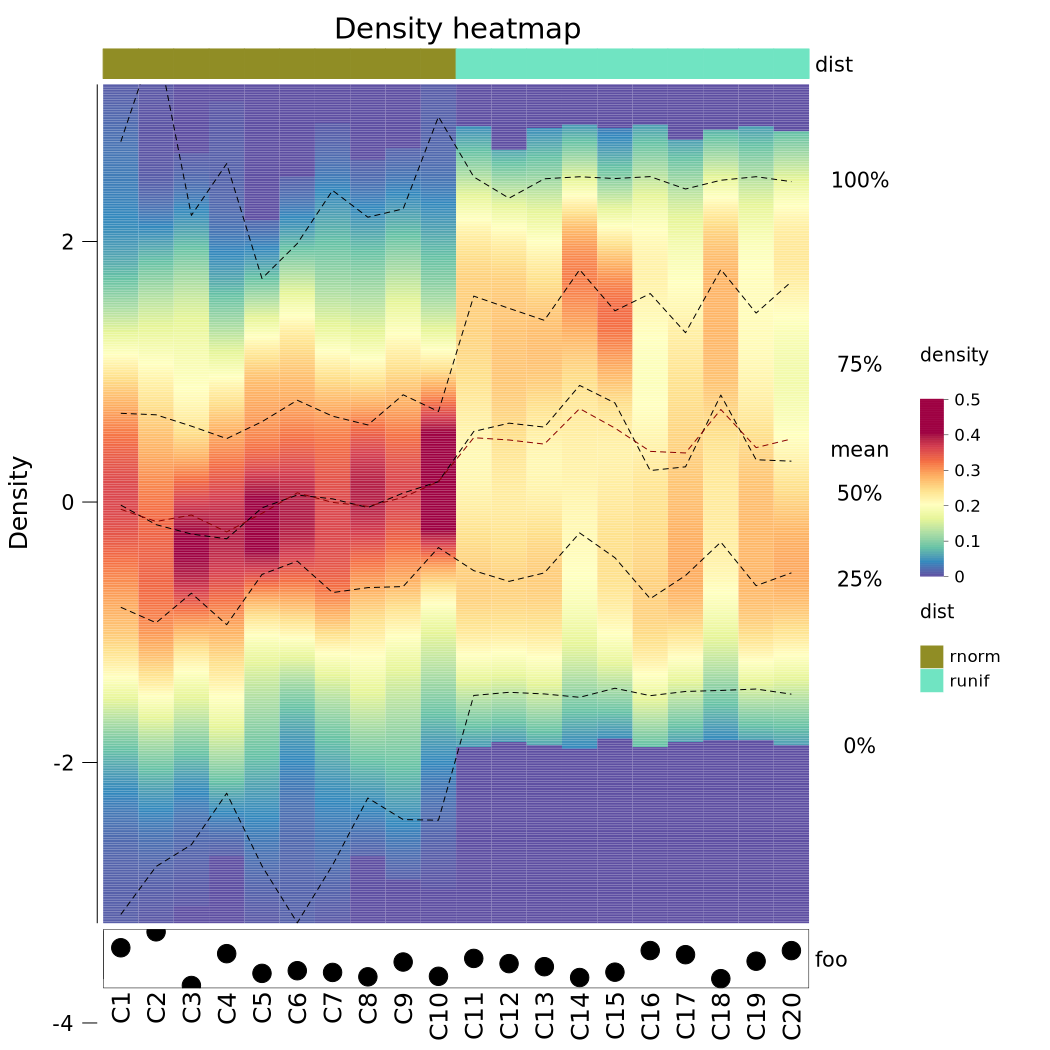

In [9]:
ha1 = HeatmapAnnotation(
    dist=np.array(["rnorm"] * 10 + ["runif"] * 10)
)
ha2 = HeatmapAnnotation(
    foo=anno_points(np.random.randn(20))
)

ht_anno = density_heatmap(
    m,
    column_names=col_names,
    top_annotation=ha1,
    bottom_annotation=ha2,
)
ht_anno.draw()

## Basic frequency heatmap

`frequency_heatmap` is a histogram-version of the density heatmap. Instead of
smooth density curves, values are binned into frequency counts (or proportions).

Returns a Heatmap: True


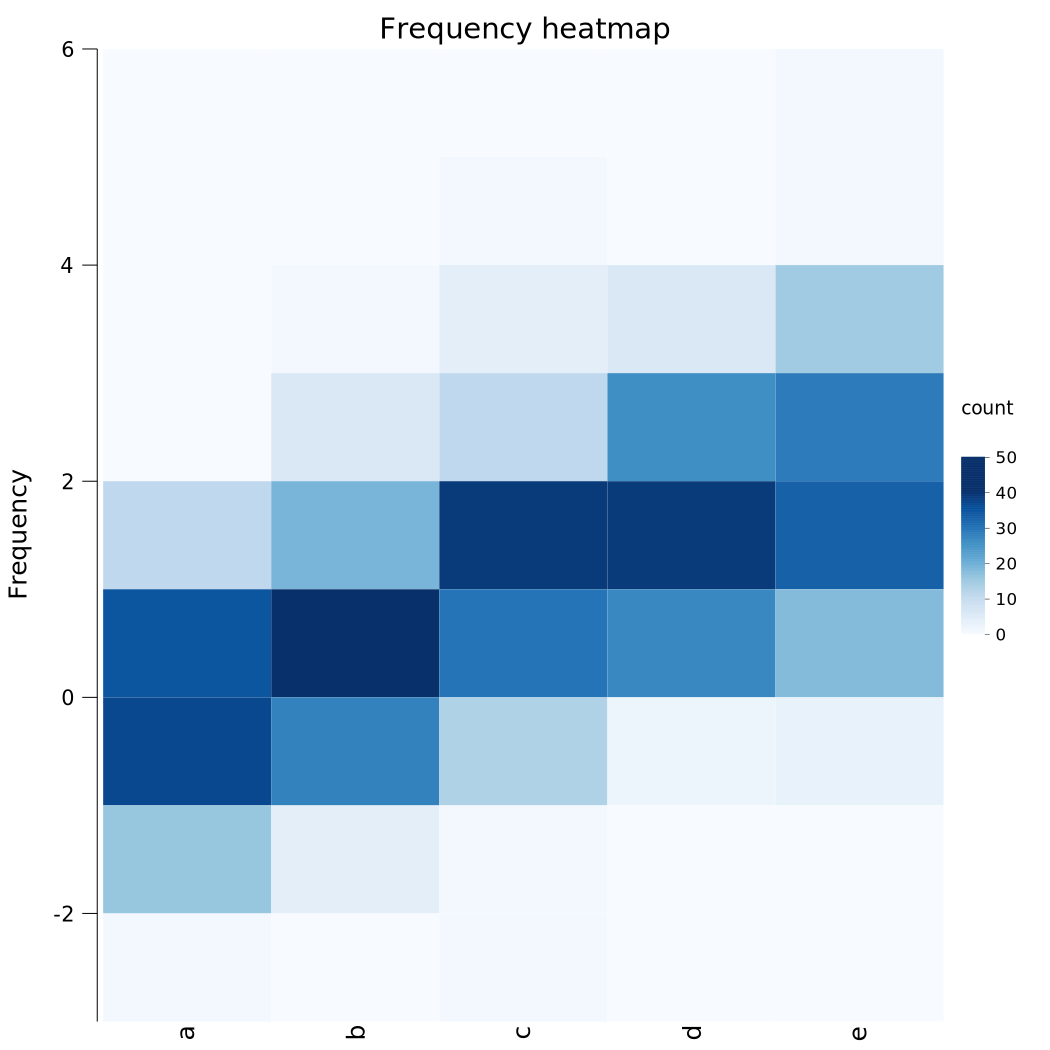

In [10]:
ht_freq = frequency_heatmap(
    data_list,
    column_names=["a", "b", "c", "d", "e"],
)
print(f"Returns a Heatmap: {isinstance(ht_freq, Heatmap)}")
ht_freq.draw()

## Verifying frequency heatmap dimensions

In [11]:
ht_freq.make_layout()
print(f"nrow = {ht_freq.nrow} (bin count)")
print(f"ncol = {ht_freq.ncol} (should be 5)")

nrow = 9 (bin count)
ncol = 5 (should be 5)


## Frequency heatmap from a matrix

Like `density_heatmap`, `frequency_heatmap` also accepts a 2D matrix.

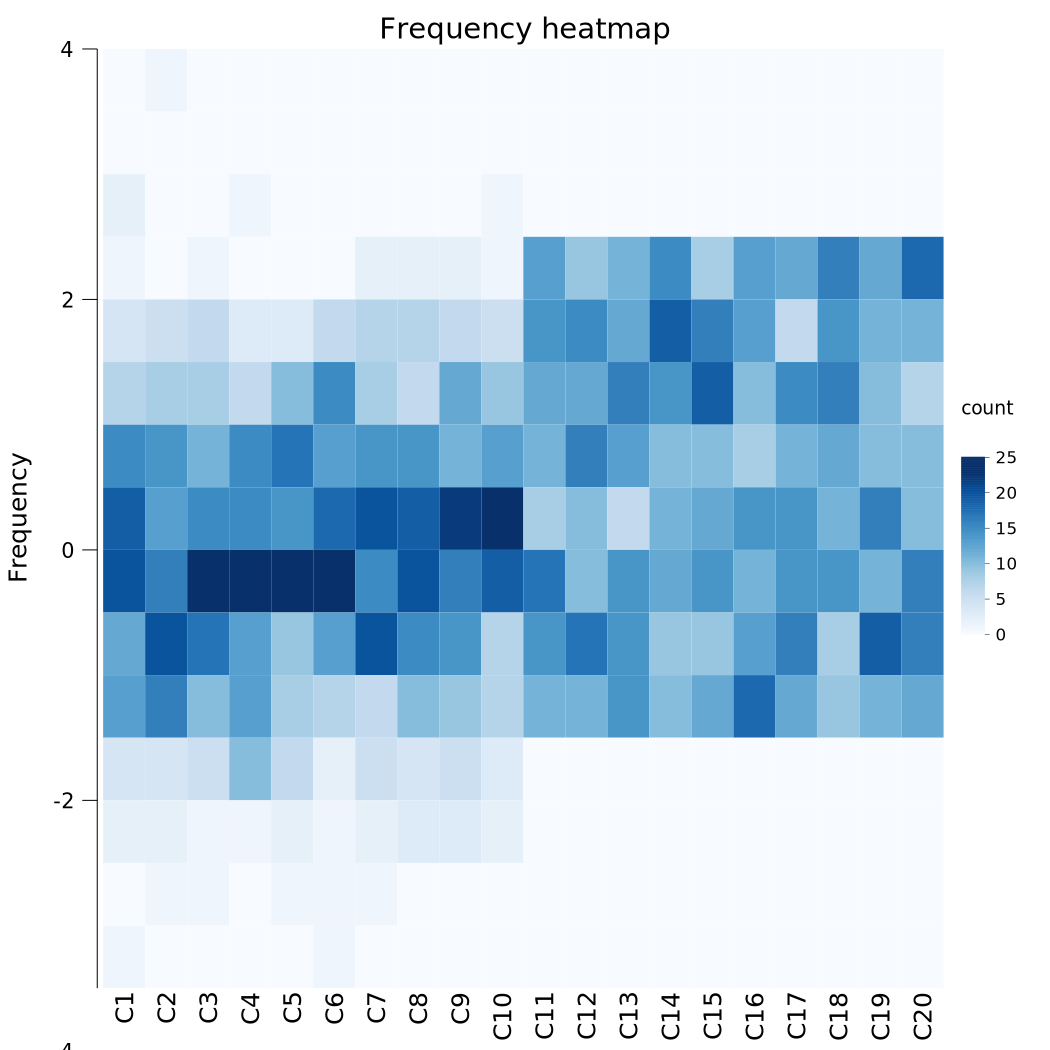

In [12]:
ht_freq_mat = frequency_heatmap(
    m,
    column_names=col_names,
)
ht_freq_mat.draw()

## Summary

This tutorial covered the high-level plotting functions:

- `density_heatmap`: density estimation per column, rendered as a color heatmap
  - Accepts matrices, 2D arrays, or lists of arrays
  - Supports column clustering (KS distance by default)
  - Works with top/bottom annotations
- `frequency_heatmap`: histogram-style binning per column
  - Same input flexibility as `density_heatmap`
  - Returns a standard `Heatmap` object for further composition